# Q1: SMOTE-Style ROC Utility Benchmark

This archived notebook starts the Question 1 experiment from `manuscript/archive/experiments/experiment_plan.md`:

> Can MIMIC match classical SMOTE-style ROC utility?

The reusable experiment machinery lives in `src/mimic_experiments/q1_smote_roc.py`. This notebook only chooses parameters, calls that module, and displays the resulting tables and plot.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src" / "mimic").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mimic import GenerationPolicy

from mimic_experiments.q1_smote_roc import (
    Q1Config,
    load_q1_result_tables,
    load_q1_dataset,
    manuscript_result_row,
    plot_q1_roc_sweep,
    print_progress_event,
    q1_dataset_registry,
    q1_result_table_manifest,
    q1_result_table_paths,
    run_mimic_roc_sweep,
)


## Experiment Controls

Edit this cell to choose the dataset, runtime profile, and MIMIC generation configuration. Use `RUN_PROFILE = "run_full"` to execute and save the full 10-fold experiment; use `RUN_PROFILE = "view"` to skip fitting and regenerate displays from the saved CSV tables.


In [2]:
# Dataset and run controls
DATASET = 6  # use a registry row number, or a key such as "adult_mixed"
RUN_PROFILE = "run_full"  # "run_full" or "view"
PROTOCOL = "paper_under_sampling"  # "paper_under_sampling" for SMOTE-paper Table 3 comparability
RANDOM_STATE = 0
N_JOBS = -1  # use all available cores for parallel fold execution
ARTIFACT_DIR = str(PROJECT_ROOT / "manuscript" / "artifacts" / "q1_smote_roc")
CACHE_MODELS = False  # keep False unless you explicitly want large per-fold .joblib model caches
WORKER_THREADS = 1  # keep BLAS/torch threads small when N_JOBS > 1

# MIMIC controls
MIMIC_MODE = "identity"  # try: identity, direct, factorised, joint
MIMIC_CAPACITY_RUN_FULL = 0.25
MIMIC_FEATURE_N_JOBS = 1  # keep 1 when outer jobs parallelize work; increase when running one job at a time

# MIMIC generation policy controls
POLICY_METHOD = "displacement"  # try: smote, displacement
POLICY_NEIGHBOUR_MODE = "normal"  # try: normal, mutual
POLICY_N_NEIGHBORS = 5
POLICY_LAMBDA_RANGE = (0.0, 1.0)

# Legacy ROC sweep controls: fraction of the training-fold minority deficit to generate
DEFICIT_FRACTIONS = (0.0, 0.25, 0.5, 0.75, 1.0)

# Paper-comparable controls: fixed SMOTE percent, then sweep majority under-sampling
SMOTE_PERCENT = 100
UNDER_SAMPLING_PERCENTAGES = (50, 100, 200, 300, 400, 500)

registry = q1_dataset_registry()
DATASET_KEY = registry.loc[DATASET, "key"] if isinstance(DATASET, int) else DATASET

config = Q1Config(
    dataset_key=DATASET_KEY,
    run_profile=RUN_PROFILE,
    random_state=RANDOM_STATE,
    protocol=PROTOCOL,
    n_jobs=N_JOBS,
    artifact_dir=ARTIFACT_DIR,
    cache_models=CACHE_MODELS,
    worker_threads=WORKER_THREADS,
    mimic_mode=MIMIC_MODE,
    mimic_capacity_run_full=MIMIC_CAPACITY_RUN_FULL,
    mimic_feature_n_jobs=MIMIC_FEATURE_N_JOBS,
    deficit_fractions=DEFICIT_FRACTIONS,
    smote_percent=SMOTE_PERCENT,
    under_sampling_percentages=UNDER_SAMPLING_PERCENTAGES,
    policy=GenerationPolicy(
        method=POLICY_METHOD,
        neighbour_mode=POLICY_NEIGHBOUR_MODE,
        n_neighbors=POLICY_N_NEIGHBORS,
        lambda_range=POLICY_LAMBDA_RANGE,
    ),
)
config


Q1Config(dataset_key='forest_cover', run_profile='run_full', random_state=0, protocol='paper_under_sampling', mimic_mode='identity', mimic_capacity_run_full=0.25, deficit_fractions=(0.0, 0.25, 0.5, 0.75, 1.0), smote_percent=100, under_sampling_percentages=(50, 100, 200, 300, 400, 500), n_jobs=-1, artifact_dir='/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/MIMIC/manuscript/artifacts/q1_smote_roc', cache_models=False, worker_threads=1, mimic_feature_n_jobs=1, policy=GenerationPolicy(method='displacement', neighbour_mode='normal', n_neighbors=5, lambda_range=(0.0, 1.0), class_conditioned=False, cluster_conditioned=False))

## Dataset Registry

The registry records the Q1 dataset distribution reported by the SMOTE paper and which loaders are available.


In [3]:
display(
    q1_dataset_registry(
        artifact_dir=ARTIFACT_DIR,
        run_profile=RUN_PROFILE,
        protocol=PROTOCOL,
        mimic_mode=MIMIC_MODE,
        mimic_capacity=config.mimic_capacity,
        smote_percent=SMOTE_PERCENT,
        under_sampling_percentages=UNDER_SAMPLING_PERCENTAGES,
        policy=config.policy,
        random_state=RANDOM_STATE,
    )
)


,key,dataset,majority,minority,status,experiment
0,pima,Pima,500,268,ready: OpenML data_id=37,complete: current summary csv
1,phoneme,Phoneme,3818,1586,ready: OpenML data_id=1489,complete: current summary csv
2,adult_mixed,Adult,37155,11687,"ready: OpenML adult v2, mixed features",not run
3,adult_numeric,Adult numeric-only,37155,11687,"ready: OpenML adult v2, numeric features only",not run
4,estate,E-state,46869,6351,optional: source needed,not run
5,satimage,Satimage,5809,626,ready: OpenML data_id=182; smallest class vs rest,complete: current summary csv
6,forest_cover,Forest Cover,35754,2747,ready: sklearn covtype classes 3 vs 4,not run
7,oil,Oil,896,41,optional: source needed,not run
8,mammography,Mammography,10923,260,ready: imbalanced-learn if installed; OpenML f...,not run
9,can,Can,435512,8360,optional: source needed,not run


## Load Dataset


In [4]:
if config.should_run_experiment:
    df = load_q1_dataset(config)
    display(df.head())
    display(df["label"].value_counts().rename_axis("label").to_frame("count"))
else:
    df = None
    print("RUN_PROFILE=view: skipping dataset load; saved CSV tables will be loaded below.")


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,label
0,2553.0,235.0,17.0,351.0,95.0,780.0,188.0,253.0,199.0,1410.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,majority
1,2011.0,344.0,17.0,313.0,29.0,404.0,183.0,211.0,164.0,300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,majority
2,2022.0,24.0,13.0,391.0,42.0,509.0,212.0,212.0,134.0,421.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,majority
3,2038.0,50.0,17.0,408.0,71.0,474.0,226.0,200.0,102.0,283.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,majority
4,2018.0,341.0,27.0,351.0,34.0,390.0,152.0,188.0,168.0,190.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,majority


,count
label,
majority,35754
minority,2747


## Run Or Reuse Q1 Sweep

`run_full` fits MIMIC inside each training fold, saves CSV result tables, and leaves validation folds untouched. `view` skips fitting and uses the CSV filenames reconstructed from `DATASET` and the config.


In [5]:
if config.should_run_experiment:
    run_mimic_roc_sweep(df, config, progress=print_progress_event)
else:
    print("RUN_PROFILE=view: skipping experiment run.")

print("Q1 result table filenames:")
for table, path in q1_result_table_paths(config).items():
    print(f"{table}: {path}")
display(q1_result_table_manifest(config))


Starting Q1 fold jobs: 0/10 complete (10 worker(s))
Completed fold 7: 1/10 folds, elapsed 47m 03s, ETA 42m 21s
Completed fold 9: 2/10 folds, elapsed 47m 13s, ETA 18m 53s
Completed fold 4: 3/10 folds, elapsed 47m 15s, ETA 11m 01s
Completed fold 5: 4/10 folds, elapsed 47m 15s, ETA 7m 05s
Completed fold 2: 5/10 folds, elapsed 48m 18s, ETA 4m 50s
Completed fold 10: 6/10 folds, elapsed 48m 26s, ETA 3m 14s
Completed fold 1: 7/10 folds, elapsed 48m 31s, ETA 2m 05s
Completed fold 6: 8/10 folds, elapsed 48m 40s, ETA 1m 13s
Completed fold 8: 9/10 folds, elapsed 48m 42s, ETA 32s
Completed fold 3: 10/10 folds, elapsed 49m 04s, ETA 0s
Q1 result table filenames:
roc_points: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/MIMIC/manuscript/artifacts/q1_smote_roc/tables/forest_cover__run_full__paper_under_sampling__identity__cap-0.25__smote-100__under-50-100-200-300-400-500__displacement-normal-k5__seed-0__roc_points.csv
summary: /run/media/fabrizio/06bb7271-2161-43a4-91f1-9

,table,path
0,roc_points,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...
1,summary,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...


## Load Saved Result Tables

Performance summaries and plots below read from the CSV tables saved by the sweep.


In [6]:
roc_points, q1_summary = load_q1_result_tables(config)

display(q1_summary)
display(roc_points)


,dataset_key,run_profile,protocol,n_rows,n_splits,n_jobs,mimic_mode,mimic_capacity,smote_percent,under_sampling_percentages,artifact_dir,roc_curve_auc,mean_fold_auc_at_balanced_under_sampling
0,forest_cover,run_full,paper_under_sampling,38501,10,-1,identity,0.25,100,"50,100,200,300,400,500",/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,0.969489,0.973137


,smote_percent,under_sampling_percent,mean_fpr,mean_tpr,mean_fold_auc,mean_generated,mean_sampled_majority,mean_sampled_minority,folds,model_cache_hits
0,100,50,0.025591,0.912269,0.971159,2472.3,9889.2,4944.6,10,0
1,100,100,0.038737,0.926843,0.973137,2472.3,4944.6,4944.6,10,0
2,100,200,0.064916,0.953774,0.968760,2472.3,2472.3,4944.6,10,0
3,100,300,0.080103,0.963593,0.965955,2472.3,1648.3,4944.6,10,0
4,100,400,0.099318,0.968694,0.961181,2472.3,1236.0,4944.6,10,0
5,100,500,0.114505,0.972338,0.958763,2472.3,989.0,4944.6,10,0


## Plot ROC Points


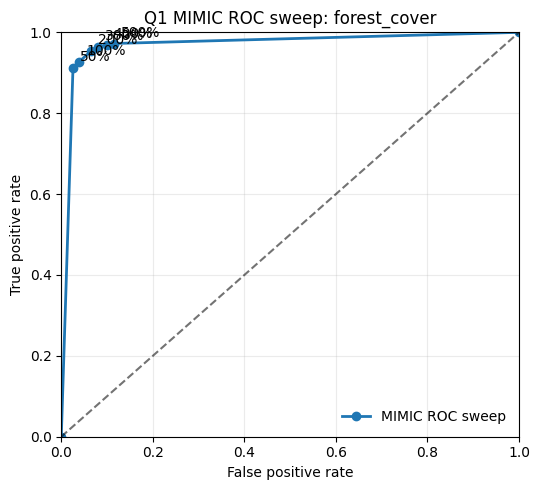

In [7]:
fig, ax = plot_q1_roc_sweep(roc_points, config)


## Result Template For Manuscript

Fill the published-reference columns from the SMOTE paper once the corresponding dataset/classifier setup is selected.


In [8]:
display(manuscript_result_row(config, q1_summary))


,dataset,classifier,published_smote_reference,mimic_auc,mimic_roc_hull_status,protocol_note
0,forest_cover,sklearn DecisionTreeClassifier,SMOTE paper ROC/AUC target,0.969489,pending hull comparison,"paper under-sampling sweep, classifier-substit..."
